In [231]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [232]:
def filter_sw(img, size, mode):
    tinggi, lebar = img.shape
    pad    = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    area   = size * size

    match mode:
        case 'mean':
            for i in range(tinggi):
                for j in range(lebar):
                    region = padded[i:i+size, j:j+size]
                    total  = 0
                    for val in region.ravel():
                        total += int(val)
                    canvas[i, j] = total // area

        case 'median':
            for i in range(tinggi):
                for j in range(lebar):
                    region = padded[i:i+size, j:j+size]
                    nilai  = list(region.ravel())
                    n = len(nilai)
                    for a in range(n):
                        for b in range(0, n - a - 1):
                            if nilai[b] > nilai[b+1]:
                                nilai[b], nilai[b+1] = nilai[b+1], nilai[b]
                    canvas[i, j] = nilai[n // 2]

        case 'modus':
            for i in range(tinggi):
                for j in range(lebar):
                    region    = padded[i:i+size, j:j+size]
                    frekuensi = {}
                    for val in region.ravel():
                        if val in frekuensi: frekuensi[val] += 1
                        else:                frekuensi[val]  = 1
                    maks     = 0
                    nilai_mo = 0
                    for val, freq in frekuensi.items():
                        if freq > maks:
                            maks     = freq
                            nilai_mo = val
                    canvas[i, j] = nilai_mo

    return canvas

In [233]:
def konvolusi(img, kernel):
    ukuran   = kernel.shape[0]
    pad_size = ukuran // 2
    padded   = np.pad(img, pad_size, mode='constant')
    canvas   = np.zeros_like(img, dtype=np.float32)
    tinggi, lebar = img.shape
    for i in range(tinggi):
        for j in range(lebar):
            region = padded[i:i+ukuran, j:j+ukuran]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

In [234]:
def deteksi_tepi(img, kernelX, kernelY):
    gx     = konvolusi(img, kernelX)
    gy     = konvolusi(img, kernelY)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)

In [235]:
def thresholding(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if img[i, j] > batas:
                canvas[i, j] = 255
            else:
                canvas[i, j] = 0
    return canvas

In [236]:
def dilasi(img, kernel):
    tinggi, lebar     = img.shape
    k_tinggi, k_lebar = kernel.shape
    center = k_tinggi // 2
    canvas = np.zeros((tinggi, lebar))
    for i in range(center, tinggi - center):
        for j in range(center, lebar - center):
            if img[i, j] == 255:
                for k in range(k_tinggi):
                    for l in range(k_lebar):
                        if kernel[k, l] == 1:
                            canvas[i+k-center, j+l-center] = 255
            else:
                if canvas[i, j] != 255:
                    canvas[i, j] = 0
    return canvas


def erosi(img, kernel):
    tinggi, lebar     = img.shape
    k_tinggi, k_lebar = kernel.shape
    center = k_tinggi // 2
    canvas = np.zeros((tinggi, lebar))
    for i in range(center, tinggi - center):
        for j in range(center, lebar - center):
            cocok = True
            for k in range(k_tinggi):
                for l in range(k_lebar):
                    if kernel[k, l] == 1 and img[i+k-center, j+l-center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                canvas[i, j] = 255
    return canvas

In [237]:
sobelX = np.array([[-1, 0, 1],
                   [-2, 0, 2],
                   [-1, 0, 1]], dtype=np.float32)

sobelY = np.array([[-1, -2, -1],
                   [ 0,  0,  0],
                   [ 1,  2,  1]], dtype=np.float32)

# Kernel dari soal untuk dilasi
kernel_soal = np.array([[0, 0, 1, 1, 1],
                        [0, 0, 1, 1, 1],
                        [1, 1, 1, 1, 1],
                        [1, 1, 1, 0, 0],
                        [1, 1, 1, 0, 0]], dtype=np.uint8)

kernel_erosi = np.array([[0, 1, 0],
                         [1, 1, 1],
                         [0, 1, 0]], dtype=np.uint8)

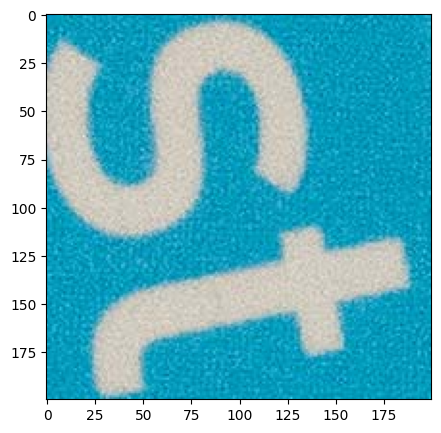

In [238]:
foto_bgr = cv2.imread('iso6400raw.jpg')
foto_rgb = cv2.cvtColor(foto_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(foto_rgb)
plt.show()

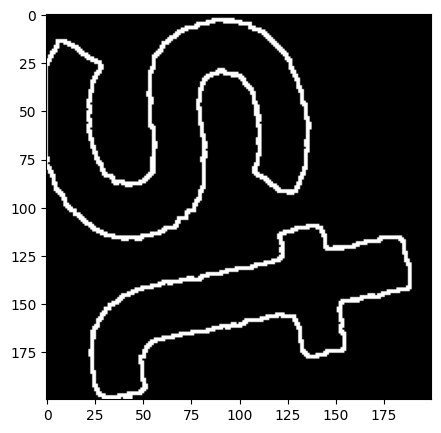

In [239]:
foto_gray   = cv2.cvtColor(foto_bgr, cv2.COLOR_BGR2GRAY)
foto_bersih = filter_sw(foto_gray, 3, 'median')

mask_objek = thresholding(foto_bersih, 150)

foto_tepi = deteksi_tepi(mask_objek, sobelX, sobelY)
mask = thresholding(foto_tepi, 10)

plt.figure(figsize=(5, 5))
plt.imshow(mask, cmap='gray')
plt.show()

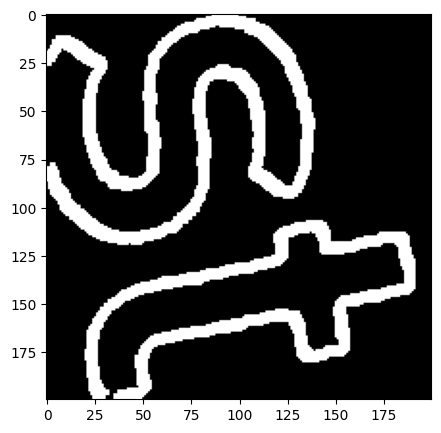

In [240]:
mask_tebal = dilasi(mask, kernel_soal)

plt.figure(figsize=(5, 5))
plt.imshow(mask_tebal, cmap='gray')
plt.show()

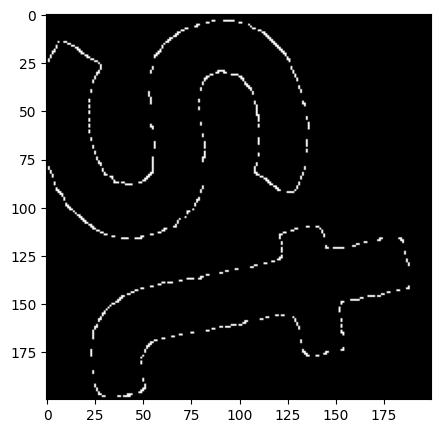

In [241]:
mask_tipis = erosi(mask, kernel_erosi)

plt.figure(figsize=(5, 5))
plt.imshow(mask_tipis, cmap='gray')
plt.show()

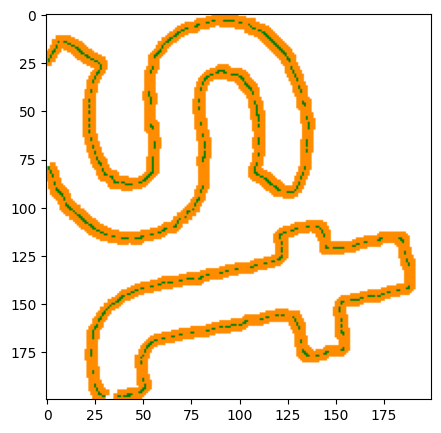

In [242]:
hasil_akhir = foto_rgb.copy()

# Seluruh area dilasi → oranye
area_oranye = mask_tebal == 255
hasil_akhir[area_oranye] = [255, 140, 0]

# Area erosi (dalam) → hijau, menimpa oranye
area_hijau = mask_tipis == 255
hasil_akhir[area_hijau] = [0, 128, 0]

# Background → putih
area_background = mask_tebal == 0
hasil_akhir[area_background] = [255, 255, 255]

plt.figure(figsize=(5, 5))
plt.imshow(hasil_akhir)
plt.show()